In [47]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [48]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d

In [49]:
args = mnist1d.data.get_dataset_args()
data = mnist1d.data.get_dataset(args, path="./mnist1d_data.pkl", download=False, regenerate=False)

Successfully loaded data from ./mnist1d_data.pkl


In [50]:
# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Length of each example: {}".format(data['x'].shape[-1]))

Examples in training set: 4000
Examples in test set: 1000
Length of each example: 40


In [ ]:
Di = 40
D_k = 400
D_o = 10

model = nn.Sequential(
  nn.Linear(Di, D_k),  
  nn.ReLU(),
  nn.Linear(D_k, D_k), 
  nn.ReLU(),
  nn.Linear(D_k, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_k),
  nn.ReLU(),
  nn.Linear(D_k, D_o)
)

def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

model.apply(weights_init)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\4087713792.py:19: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(layer_in.weight)


Sequential(
  (0): Linear(in_features=40, out_features=250, bias=True)
  (1): ReLU()
  (2): Linear(in_features=250, out_features=250, bias=True)
  (3): ReLU()
  (4): Linear(in_features=250, out_features=250, bias=True)
  (5): ReLU()
  (6): Linear(in_features=250, out_features=250, bias=True)
  (7): ReLU()
  (8): Linear(in_features=250, out_features=10, bias=True)
)

In [52]:
loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), momentum=0.9)

scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

x_train = torch.tensor(data["x"].astype("float32"))
y_train = torch.tensor(data["y"].transpose().astype("int64"))
x_test = torch.tensor(data["x_test"].astype("float32"))
y_test = torch.tensor(data["y_test"].astype("int64"))

In [53]:
x_test.shape

torch.Size([1000, 40])

**1. The Reset: `optimizer.zero_grad()`**
**What it does:** It deletes the gradients calculated in the *previous* iteration.
**Why is it essential?** PyTorch is designed to **accumulate** (add up) gradients by default.
* If you don't zero them out, the gradients from Batch 1 will be added to Batch 2, then Batch 3, etc.
* By the end of the epoch, your gradient values would be gigantic, causing the model to diverge (explode) instead of learn.
* *Analogy:* Think of this like erasing a whiteboard before solving a new math problem. If you don't erase the old numbers, you can't read the new solution.

**2. The Forward Pass: `pred = model(x_batch)`**
**What it does:** It pushes the input data ($x\_batch$) through the network layers you defined earlier.
**The Mechanism:**
* It performs the matrix multiplications (Linear layers).
* It applies the activation functions (ReLU).
* It generates the final output (`pred`).
* **Crucially:** As this happens, PyTorch builds a **Computational Graph** in memory, tracking exactly which operations were performed so it knows how to reverse them later.

**3. The Critique: `loss = loss_function(pred, y_batch)`**
**What it does:** It compares the model's guess (`pred`) against the actual answer (`y_batch`).
**The Result:** It produces a single scalar number (the Loss) representing "how bad" the model's prediction was.
* High Loss = Bad prediction.
* Low Loss = Good prediction.

**4. The Backward Pass: `loss.backward()`**
**What it does:** This is the "learning" calculation (Backpropagation).
**The Mechanism:**
1.  It starts at the Loss value.
2.  It traverses backward through the computational graph (from Output $\to$ Input).
3.  It calculates the gradient (the partial derivative) of the loss with respect to **every single weight and bias** in the network.
4.  It stores these gradients inside the parameter tensors themselves (specifically in the `.grad` attribute).



**5. The Update: `optimizer.step()`**
**What it does:** It modifies the weights to reduce the error.
**The Math:** It takes the current weight and subtracts a tiny fraction of the gradient.
$$W_{new} = W_{old} - (\text{learning\_rate} \times \text{gradient})$$

* If the gradient is positive (slope goes up), it moves the weight down.
* If the gradient is negative (slope goes down), it moves the weight up.
* After this line executes, your model is slightly "smarter" than it was a millisecond ago.

---

**1. The Setup (The "Nano" Network)**

Imagine a network that takes one input, multiplies it by one weight, and tries to match a target.

* **Input ($x$):** $2.0$
* **Weight ($w$):** $3.0$ (This is what the model learns)
* **Target ($y$):** $10.0$
* **Learning Rate:** $0.01$

We want the model to output $10$, but right now with a weight of $3$, it will output $6$ ($2 \times 3$). It is wrong. Let's trace the math.


**2. The Forward Pass (Calculating Loss)**

Before we can go backward, we must go forward to build the "Graph."

1.  **Prediction ($a$):**
    $$a = x \cdot w$$
    $$a = 2.0 \cdot 3.0 = 6.0$$

2.  **Loss ($L$):** (Using Mean Squared Error: $(guess - answer)^2$)
    $$L = (a - y)^2$$
    $$L = (6.0 - 10.0)^2 = (-4.0)^2 = 16.0$$

**Current State:** The Loss is **16.0**. To improve, we need to lower this number.

**3. The Backward Pass (`loss.backward()`)**

When you call `loss.backward()`, the computer asks: **"How much did the weight ($w$) contribute to this error ($L$)?"**

Since $w$ didn't touch $L$ directly (it went through $a$), we use the **Chain Rule**:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \times \frac{\partial a}{\partial w}$$

Let's calculate these two parts step-by-step:

**Step A: How does the Loss change if the Prediction ($a$) changes?**
We look at the equation $L = (a - y)^2$.
Using simple calculus (power rule), the derivative is:
$$\frac{\partial L}{\partial a} = 2 \cdot (a - y)$$

Plug in our numbers:
$$2 \cdot (6.0 - 10.0) = -8.0$$

**Intuition:** This $-8.0$ tells us "The prediction was too low; we need to push it up."

**Step B: How does the Prediction ($a$) change if the Weight ($w$) changes?**
We look at the equation $a = x \cdot w$.
The derivative of $w \cdot x$ with respect to $w$ is simply $x$:
$$\frac{\partial a}{\partial w} = x$$

Plug in our numbers:
$$\text{Input } x = 2.0$$

**Intuition:** This tells us "Any change in the weight is doubled by the input."

**Step C: Combine them (The Chain Rule)**
Now we multiply Step A and Step B to find the final gradient for $w$.

$$\text{Gradient} = -8.0 \times 2.0 = -16.0$$

**Result:** The gradient of $w$ is **-16.0**.
* The negative sign means "Increasing the weight will decrease the loss."
* The magnitude (16) is quite strong because the error was large.

---

**4. The Optimization (`optimizer.step()`)**

Now we use that gradient to update the weight.
$$w_{new} = w_{old} - (\text{learning\_rate} \times \text{gradient})$$

$$w_{new} = 3.0 - (0.01 \times -16.0)$$
$$w_{new} = 3.0 - (-0.16)$$
$$w_{new} = 3.16$$

Did it work?
Let's check with the new weight ($3.16$):
* **New Prediction:** $2.0 \times 3.16 = \mathbf{6.32}$
* **Target:** $10.0$

We moved from $6.0$ to $6.32$. We are closer to the target! The loss has decreased. This is exactly what happens millions of times in your loop.

***

In [54]:
data_loader = DataLoader(TensorDataset(x_train, y_train), 
                         batch_size=100,
                         shuffle=True,
                         worker_init_fn=np.random.seed(1))

model.apply(weights_init)

n_epoch = 200

losses_train = np.zeros((n_epoch))
errors_train = np.zeros((n_epoch))
losses_test = np.zeros((n_epoch))
errors_test = np.zeros((n_epoch))

for epoch in range(n_epoch):
  for i, batch in enumerate(data_loader):
    x_batch, y_batch = batch
    optimizer.zero_grad()
    
    pred = model(x_batch)
    
    loss = loss_function(pred, y_batch)
    
    loss.backward()
    
    optimizer.step()
    
  pred_train = model(x_train)
  pred_test = model(x_test)
  _, predicted_train_class = torch.max(pred_train.data, 1)
  _, predicted_test_class = torch.max(pred_test.data, 1)
  errors_train[epoch] = 100 - 100 * (predicted_train_class == y_train).float().sum() / len(y_train)
  errors_test[epoch]= 100 - 100 * (predicted_test_class == y_test).float().sum() / len(y_test)
  losses_train[epoch] = loss_function(pred_train, y_train).item()
  losses_test[epoch]= loss_function(pred_test, y_test).item()
  print(f'Epoch {epoch:5d}, train loss {losses_train[epoch]:.6f}, train error {errors_train[epoch]:3.2f},  test loss {losses_test[epoch]:.6f}, test error {errors_test[epoch]:3.2f}')

  scheduler.step()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\4087713792.py:19: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(layer_in.weight)


Epoch     0, train loss 2.076432, train error 75.95,  test loss 2.111489, test error 78.20
Epoch     1, train loss 1.870790, train error 70.22,  test loss 1.923295, test error 74.70
Epoch     2, train loss 1.755980, train error 66.30,  test loss 1.835847, test error 72.80
Epoch     3, train loss 1.677862, train error 63.45,  test loss 1.773131, test error 71.00
Epoch     4, train loss 1.612639, train error 59.90,  test loss 1.726960, test error 69.90
Epoch     5, train loss 1.568801, train error 59.05,  test loss 1.701825, test error 68.90
Epoch     6, train loss 1.521150, train error 56.47,  test loss 1.663558, test error 67.10
Epoch     7, train loss 1.478356, train error 53.80,  test loss 1.640731, test error 66.20
Epoch     8, train loss 1.444905, train error 52.60,  test loss 1.615644, test error 65.30
Epoch     9, train loss 1.411735, train error 50.65,  test loss 1.599956, test error 65.10
Epoch    10, train loss 1.390060, train error 50.00,  test loss 1.581705, test error 64.80

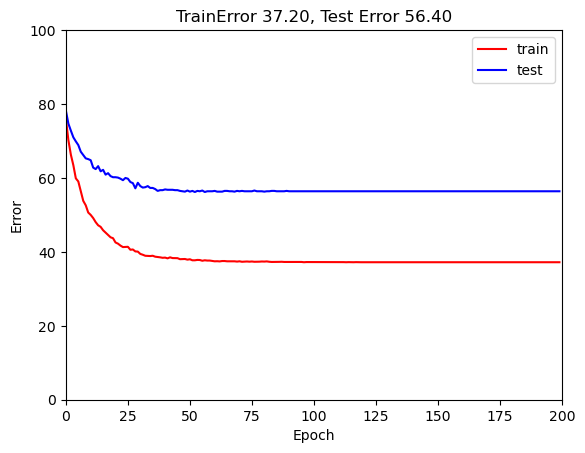

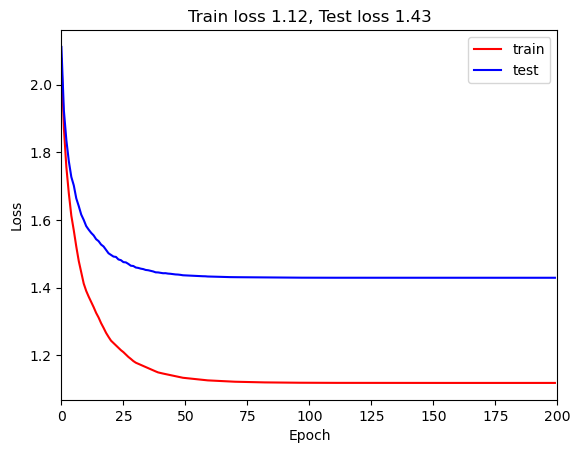

In [55]:
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='train')
ax.plot(errors_test,'b-',label='test')
ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Error')
ax.set_title('TrainError %3.2f, Test Error %3.2f'%(errors_train[-1],errors_test[-1]))
ax.legend()
plt.show()

# Plot the results
fig, ax = plt.subplots()
ax.plot(losses_train,'r-',label='train')
ax.plot(losses_test,'b-',label='test')
ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Train loss %3.2f, Test loss %3.2f'%(losses_train[-1],losses_test[-1]))
ax.legend()
plt.show()